# Trabajo practico N3 - Procesamiento del Habla - 2c2025

**Alumno: Brian Alex Fuentes Acuña**

**Padrón: 101785**

---

Esta entrega está basada en los programas utilizados en la guía 6. Se utilizarán como datos el archivo *data.mat*, y los algoritmos que figuran en el campus.


In [1]:
#markovData/data.mat

data_raw = "https://raw.githubusercontent.com/Alex-f98/procHabla20252c/main/markovData/data.mat"
markov = "https://raw.githubusercontent.com/Alex-f98/procHabla20252c/main/markovData/markov.py"

secev_raw = "https://raw.githubusercontent.com/Alex-f98/procHabla20252c/main/markovData/secuencia_evaluacion_BW_fuentes.mat"
seqv_raw  = "https://raw.githubusercontent.com/Alex-f98/procHabla20252c/main/markovData/secuencia_viterbi_fuentes.mat"


!wget -O data.mat "$data_raw"
!wget -O secuencia_evaluacion_BW_fuentes.mat "$secev_raw"
!wget -O secuencia_viterbi_fuentes.mat "$seqv_raw"
!wget -O markov.py "$markov"


--2025-11-11 16:15:47--  https://raw.githubusercontent.com/Alex-f98/procHabla20252c/main/markovData/data.mat
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 13952 (14K) [application/octet-stream]
Saving to: ‘data.mat’

data.mat            100%[===================>]  13.62K  --.-KB/s    in 0s      

2025-11-11 16:15:48 (112 MB/s) - ‘data.mat’ saved [13952/13952]

--2025-11-11 16:15:48--  https://raw.githubusercontent.com/Alex-f98/procHabla20252c/main/markovData/secuencia_evaluacion_BW_fuentes.mat
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 20

In [2]:
from markov import *
from matplotlib import animation
from matplotlib import patches
from matplotlib import gridspec
from mpl_toolkits import mplot3d


from threading import Event
from math import *
from random import randrange, uniform
from scipy import stats as sps
from scipy.io import loadmat

import numpy as np
from scipy.special import logsumexp
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


In [3]:
def logbw(X, hmm):
    """
    Calcula las probabilidades backward (β) en el dominio logarítmico.
    Retorna log_prob (P(x_{t+1}^{N-1}|z_t=k)) y log_beta (matriz N×T).
    """
    T = X.shape[0]                 # cantidad de observaciones
    N = hmm.numStates - 2          # sin contar inicio y fin

    tmp = np.copy(hmm.trans)
    tmp[tmp < 1e-320] = 1e-320
    log_A = np.log(tmp)

    # log_b[k,t] = log p(x_t | z_t = k) / j={k=1..k=N}, X={x1...xT}
    log_b = -np.ones((N,T))*np.log(2*np.pi)
    for k in range(N):#para todo T->:
        log_b[k,:] -= 0.5 * np.log(np.linalg.det(hmm.vrs[k]))
        x_unbiased = X - hmm.means[k,np.newaxis]
        inv_sig =  np.linalg.inv(hmm.vrs[k])
        log_b[k,:] -= 0.5 * np.einsum('ij,ij->i',x_unbiased @ inv_sig, x_unbiased).T


    # Inicialización: β_T(j) = a_{j,N}
    log_beta = np.zeros((N, T))
    log_beta[:, -1] = log_A[1:-1, -1]

    # Recursión hacia atrás: t = T-2, T-3, ..., 0
    for t in range(T - 2, -1, -1):
        for k in range(N):
            # log β_t(k) = log Σ_h a_{kh} * b_h(x_{t+1}) * β_{t+1}(h)
            log_beta[k, t] = logsumexp(
                log_A[k + 1, 1:-1] + log_b[:, t + 1] + log_beta[:, t + 1]
            )

    log_prob = logsumexp(log_A[0, 1:-1] + log_b[:, 0] + log_beta[:, 0])

    return log_prob, log_beta

In [4]:
aux = [];aux.append(np.inf)
aux

[inf]

In [5]:
#Lo dejo por completitud, para estos ejemplos en pocas iteraciones
# esto funciona muy bien sin necesidad de Kmeans u otra forma de inicializacion
class Kmeans:
  def __init__(self,K,it=500):
    self.K = K
    self.it = it
    self.labels_ = None
    self.cluster_centers_ = None

  def fit(self,X):
    self.cluster_centers_ = self._inicializar(X,self.K)
    for i in range(self.it):
      self.labels_ = self._minimization(X,self.cluster_centers_)
      self.cluster_centers_ = self._expectation(X,self.labels_)
    return self

  def predict(self,X):
    return self._minimization(X,self.cluster_centers_)

  def _inicializar(self,X,num_clusters):
    idx_centroides = np.random.choice(X.shape[0], size=num_clusters, replace=False)
    return X[idx_centroides,:]

  #clasifico
  def _minimization(self,X,centroides):
    d2 = np.sum((X[:,:,np.newaxis] - centroides[:,:,np.newaxis].T)**2,axis=1)
    clasificacion = np.argmin(d2,axis=1)
    return clasificacion

  # calculo centroides
  def _expectation(self,X,clasificacion):
    c = np.unique(clasificacion).shape[0]
    centroides = np.empty((c,X.shape[1]))
    for k in range(c):
      centroides[k,:] = X[clasificacion == k,:].mean(axis=0)
    return centroides

In [6]:
class BaumWech:
    def __init__(self, hmm, max_it=500, eps=1e-4, info=False):
        #self.K      = K #Acá la cantidad de cluster esta dada por el modelo o X, seria N.
        self._it     = max_it
        self._eps    = eps
        self._info   = info
        self.hmm    = hmm
        self.T      = None
        self.N      = hmm.numStates-2
        self.log_likelihood = []; self.log_likelihood.append(np.inf)
        self.mu     = []; self.mu.append(self.hmm.means)
        self.var    = []; self.var.append(self.hmm.vrs)


    def fit(self, X, init_kmeans=False):
        self.T = X.shape[0]
        if init_kmeans: self._inicializar(X, self.N)
        for i in range(self._it):
            log_posteriors, log_xi = self._expectation(X)
            self._maximization(X, np.exp(log_posteriors), np.exp(log_xi))

            #sale del logfw en el paso E.
            if np.abs(self.log_likelihood[i]- self.log_likelihood[i+1]) < self._eps:
                print(f"(iter: {i}) Entrenamiento exitoso!!")
                return

    def history_likehood(self):
        return self.log_likelihood[1:]

    def predict_proba(self,X):
        log_prob, _ = self._expectation(X)
        return log_prob

    def predict(self,X):
        return np.argmax(self.predict_proba(X),axis=1)

    def _inicializar(self, X, num_clusters):
        kmeans = Kmeans(K=num_clusters).fit(X)
        medias = kmeans.cluster_centers_
        clasificacion_sk = kmeans.labels_
        pesos = np.empty(num_clusters)
        vars  = np.empty((num_clusters, self.medias.shape[1], self.medias.shape[1]))

        for k in range(num_clusters):
            pesos[k]= np.mean(clasificacion_sk==k)
            vars[k] = np.cov(X[clasificacion_sk==k].T)

        self.hmm.means = medias
        self.hmm.vrs = vars

    def _get_model(self, X, hmm, N, T):
        tmp = np.copy(hmm.trans)
        tmp[tmp < 1e-320] = 1e-320
        log_a = np.log(tmp)

        log_b = -np.ones((N,T))*np.log(2*np.pi)
        for k in range(N): #para todo T->:
            log_b[k,:] -= 0.5 * np.log(np.linalg.det(hmm.vrs[k]))
            x_unbiased  = X - hmm.means[k,np.newaxis]
            inv_sig     =  np.linalg.inv(hmm.vrs[k])
            log_b[k,:] -= 0.5 * np.einsum('ij,ij->i',x_unbiased @ inv_sig, x_unbiased).T
        return log_a, log_b.T

    def _expectation(self,X):
        """
        Calculo las responsabilidades:
                    α_t(j),β_t(j)
        γt(j)   =  -----------------
                    ∑_∀j αt(i),βt(i)

                    α_{t−1}(k) a_{kj} b_j(xt) β_t(j)
        ξt(k,j) =   --------------------------------
                        ∑_∀j αt(i),βt(i)

        Retorna: log_gamma, log_xi
        """
        #Queremos que el tiempo vaya primero para vectorizar.
        log_prob, log_alpha = logfw(X, self.hmm)
        _, log_beta  = logbw(X, self.hmm)

        self.log_likelihood.append(log_prob)

        T = len(X)

        log_alpha, log_beta = log_alpha.T, log_beta.T                #(T, N), (T, N)
        log_a, log_b = self._get_model(X, self.hmm, self.N, len(X))  #(N, N), (T, N)

        logSumNk = logsumexp(log_alpha + log_beta, axis=1)[1]              #Solo calculo uno SON CTES ! x T

        # log γt(j)
        log_gamma = np.zeros((T, self.N))
        log_gamma = (log_alpha + log_beta) - logSumNk


        #log ξt(k,j) index: (t, k,j)
        log_xi = np.zeros((T-1, self.N, self.N))
        log_xi = (
            log_alpha[:-1, :, None]                       # (T-1, N, 1)
            + log_a[None, 1:self.N+1, 1:self.N+1]         # (1  , N, N) / log_A.shape=(N+2,N+2)
            + np.transpose(log_b[1:, None, :], (0, 1, 2)) # (T-1, 1, N)
            + log_beta[1:, None, :]                       # (T-1, 1, N)
        )
        log_xi -= logSumNk

        return log_gamma, log_xi


    def _maximization(self, X, posteriors, xi):
        #A
        self.hmm.trans[1:self.N+1, 1:self.N+1] =  np.sum(xi, axis = 0) / np.sum(posteriors, axis = 0)
        self.hmm.trans[self.N, self.N+1]       = 1 - np.sum(self.hmm.trans[self.N,:-1])            #prob. de caer al est. final

        S = np.sum(posteriors, axis=0)
        self.hmm.means= posteriors.T @ X / S[:,np.newaxis] #mu

        aux = np.einsum('nka,nkb->nkab', X[:,np.newaxis]-self.hmm.means, X[:,np.newaxis]-self.hmm.means)
        self.hmm.vrs  = np.einsum('nkab,nk->kab', aux, posteriors) / S[:,np.newaxis,np.newaxis] #v

        if self._info: #para graficar.
            self.mu.append(self.hmm.means)
            self.var.append(self.hmm.vrs)


In [7]:
def get_cov_ellipse(cov, centre, nstd, **kwargs):
    """
    Return a matplotlib Ellipse patch representing the covariance matrix
    cov centred at centre and scaled by the factor nstd.
    ref: https://scipython.com/book/chapter-7-matplotlib/examples/bmi-data-with-confidence-ellipses/
    """
    from matplotlib.patches import Ellipse

    # Find and sort eigenvalues and eigenvectors into descending order
    eigvals, eigvecs = np.linalg.eigh(cov)
    order = eigvals.argsort()[::-1]
    eigvals, eigvecs = eigvals[order], eigvecs[:, order]

    # The anti-clockwise angle to rotate our ellipse by
    vx, vy = eigvecs[:,0][0], eigvecs[:,0][1]
    theta = np.arctan2(vy, vx)

    # Width and height of ellipse to draw
    width, height = 2 * nstd * np.sqrt(eigvals)
    return Ellipse(xy=centre, width=width, height=height,
                   angle=np.degrees(theta), **kwargs)


def plot_cov(x, z, model, title_ = 'Covarianzas obtenidas con Baum-Wech', ellipse=None):
    Σ  = model.vrs
    µy = model.means

    #vocales = {"a": None, "o": None, "u": None}
    vocales = {"1": None, "2": None, "3": None}
    colours = ['magenta', 'blue', 'orange']

    for idx, vocal in enumerate(vocales):
        vocales[vocal] = x[z == (idx+1)]

    # Gráfico
    fig, ax = plt.subplots()
    for i, (vocal, datos) in enumerate(vocales.items()):
        ax.scatter(datos[:,0], datos[:,1], color=colours[i], label = vocal)

        ax.scatter(µy[i][0], µy[i][1], color=colours[i], marker='*', s=200, edgecolors='black')
        e = get_cov_ellipse(Σ[i], µy[i], 1.7, fc=colours[i], alpha=0.4)
        ax.add_patch(e)
        if ellipse: ax.add_patch(ellipse[i])

    #ax.set_xlabel('formante 1')
    #ax.set_ylabel('formante 2')   ...ACA tecnicamente nose que son!
    plt.title(title_)
    ax.legend(loc='upper left', scatterpoints=1)
    plt.show()
    return fig, ax


## 1

Se debe realizar un entrenamiento de los parámetros de un modelo oculto de Markov utilizando el algoritmo Baum-Wech. Para ello se dispone de una secuencia de entrenamiento que fue generada por el Modelo HMM[3] (cuarto modelo suministrado en *data.mat*).

-    Inicializar los parámetros $Θ(0) = \{ μ^{(0)}_k, Σ^{(0)}_k,\  k = 1, …, K − 2 \} ∪ A^{(0)}$ , del siguiente modo: para las medias y las varianzas tomar la media global de la secuencia y la covarianza general. Para la matriz de transición, considere un modelo de Bakis equiprobable.

-   Deben calcularse la matriz $P(z_t = k | X) = γ_t(k)$ para $t = 0, …, T − 1$ y $k = 1, …, K − 2$, con K el número de estados (incluyendo el inicial y final no emisores); y también la matriz de matrices $P(z_t−1 = j, z_t = k | X) = ξ_t(j, k)$, utilizando los parámetros de la iteración anterior $Θ^{(iter−1)} = {μ^{(iter−1)}_k, Σ^{(iter−1)}_k, k = 1, …, K − 2} ∪ A^{(iter−1)}$ (Paso E).

-   Utilizando las matrices de probabilidad anteriores, calcular los parámetros actualizados ($Θ^{(iter)}$) de la iteración siguiente (Paso M). Iterar varias veces entre el paso E (ítem anterior) y este paso M hasta que la probabilidad de la secuencia $P(X)$ para esos dados parámetros $Θ^{(iter)}$ (likelihood) ya no aumente más con las sucesivas iteraciones.

-   Una vez realizadas las iteraciones anteriormente mencionadas, se compararán los parámetros obtenidos ($Θ^{(final)}$) con los reales del modelo original.

-   Realizar un gráfico por cada iteración mostrando la evolución de los parámetros mediante el gráfico de las medias y las curvas de nivel de las gaussianas. Dibuje en los gráficos cada punto $x_t$ con el color correspondiente a la terna ($γ_t(1), γ_t(2), γ_t(3)$). Imprima la matriz de transición obtenida y la original.


In [8]:
#hmm1, hmm2, hmm3, hmm4, hmm5, hmm6, hmm7 = GenData()

x = loadmat('data.mat')
X1, X2, X3, X4, X5, X6 = x['X1'], x['X2'], x['X3'], x['X4'], x['X5'], x['X6']
Z1 = x['ST1'].astype(int)[0]-1
Z2 = x['ST2'].astype(int)[0]-1
Z3 = x['ST3'].astype(int)[0]-1
Z4 = x['ST4'].astype(int)[0]-1
Z5 = x['ST5'].astype(int)[0]-1
Z6 = x['ST6'].astype(int)[0]-1

HMM = GenData() # un array de modelos

Se va a programar el algoritmo de *Baum-wech* el cual es una variante del algortimo EM (una adaptación para HMMs) y este permite , mediante un proceso iterativo, hallar los parametros que maximizan la verosimilitud de las secuencias de observaciones de los datos de entrenamiento.

Este algortimo tampoco garantiza encontrar un maximo global.

Se trabaja con el modelo de Bakis por lo que para el problema:

- Se inicializa el modelo de bakis, con medias y varianzas tomadas como las globales de los datos $X$ completos.

- Se considela el modelo de bakis equiprobable.


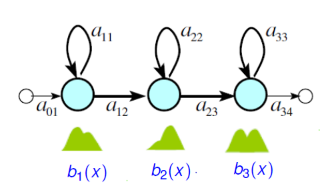

Donde los estados son $ \{ \text{Inicio}, S_1, S_2, S_3, \text{Fin} \}$

y los parametros son:

$Θ(0) = \{ μ^{(0)}_k, Σ^{(0)}_k,\  k = 1, …, K − 2 \} ∪ A^{(0)}$

$$
\begin{align}
A &= P(Z_t = j | Z_{t-1}=i)=
\begin{bmatrix}
0   & 1   & 0   & 0   & 0 \\
0   & 0.5 & 0.5 & 0   & 0 \\
0   & 0   & 0.5 & 0.5 & 0 \\
0   & 0   & 0   & 0.5 & 0.5 \\
0   & 0   & 0   & 0   & 0
\end{bmatrix}
\\
μ^{(0)}_k &= \frac1T\sum_\limits{t=1}^{T}X \\
Σ^{(0)}_k &= \frac1T\sum_\limits{t=1}^{T} (X- μ^{(0)}_k)^T (X- μ^{(0)}_k)
\end{align}
$$




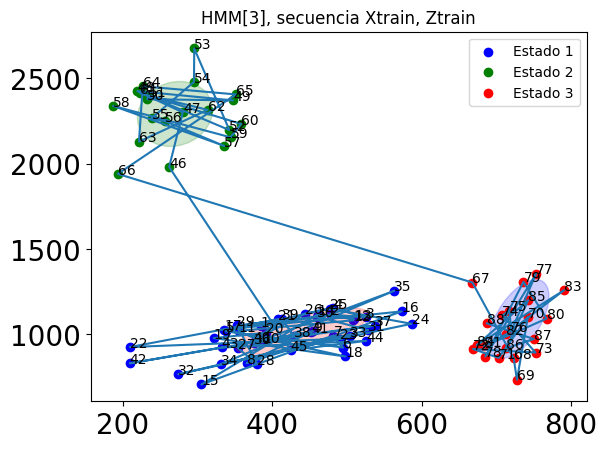

In [9]:
X_train, Z_train= genhmm(HMM[4])
min_state = 20
while not (np.bincount(Z_train)[1:-1] >= min_state).all():
 X_train, Z_train= genhmm(HMM[4])
 #print(np.bincount(Z_train)[1:-1])


ax = plotseq2(HMM[3], Z_train, X_train, gauss=True)
ax.set_title('HMM[3], secuencia Xtrain, Ztrain')

#Defino los parametros de arranque
means = np.ones((3,2))*np.mean(X_train,axis=0)
vrs   = np.ones((3, 2,2))*np.cov(X_train, rowvar=False)
trans = np.array([
                    [0.0, 1.0, 0.0, 0.0, 0.0],
                    [0.0, 0.5, 0.5, 0.0, 0.0],
                    [0.0, 0.0, 0.5, 0.5, 0.0],
                    [0.0, 0.0, 0.0, 0.5, 0.5],
                    [0.0, 0.0, 0.0, 0.0, 1.0]
                ])

hmm_brian = hmm(means, vrs, trans)

Ok, veamos la covarianza inicial de todas las muestras obtenidas, esta covarianza se le asignara a cada una de las tres clases que tiene  el modelo.

Asignar una covarianza inicial en comun para todos es un criterio de inicio pero pueden usarse otros, como la de uniformidad temporal para clacular distintas covarianzas iniciales por clase o agrupar clusters con kmeans y de ahí obtener parametros iniciales.

Para los ejemplos pedidos con la inicializacion propuesta es suficiente, en pocas iteraciones se llega a la solución.

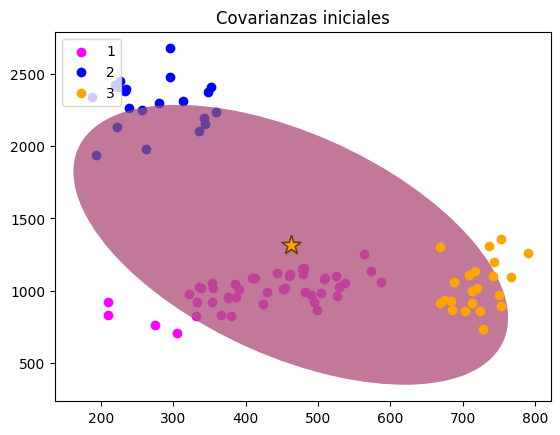

(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'Covarianzas iniciales'}>)

In [10]:
plot_cov(X_train, Z_train[1:-1], hmm_brian, 'Covarianzas iniciales')

### Computo de parametros del modelo


**Paso E:**

Primero se deben calcular los parametros $α$ y $β$ como las recursiones forward y backward respectivamente.


$$
\alpha_t(k) = p(X_1^t, z_t = k) = b_k(x_t) \sum_{j=1}^{N-1} a_{jk} \alpha_{t-1}(j)
\\
\alpha_1(k) = b_k(x_1) π_k = b_k(x_1) a_{0k}
$$


$$
\beta_t(k) = p(X_{T+1}^T | z_t = k) = \sum_{j=1}^{N-1} a_{kj} b_j(x_{t+1}) \beta_{t+1}(j) \\
\beta_T(j) = a_{jN}
$$

Donde el parametro  $\beta_T(j)$  no se puede calcular de $p(X_{T+1}^T | z_t = j)$ esto no tiene sentido!
pero si se puede calcular el $β$ dado que se tiene que cumplir lo siguiente.

$$
\mathcal{P}(X^T_1) = \sum_{j=1}^{N-1} \mathcal{P}(X^T_1, z_t = j) = \sum_{j=1}^{N-1} \alpha_t(j) \cdot \beta_t(j) = \sum_{j=1}^{N-1} \alpha_t(j) a_{jN}  
\\
= cte. ∀t
$$

Finalmente se calculan los siguientes parametros a posteriori.

* **Responsabilidad**
$$
\gamma_t(j) = P(z_t = j \mid x_1^T)
= \frac{P(x_1^T, z_t = j)}{P(x_1^T)}
= \frac{\alpha_t(j), \beta_t(j)}{\sum_j \alpha_t(j), \beta_t(j)}
$$

* **Respoinsabilidad conjunta para dos estados contiguos**
$$
\xi_t(k,j) = P(z_{t+1} = k, z_{t} = j \mid X)
= \frac{\alpha_{t-1}(k) \ a_{kj}\  b_j(x_{t})\  \beta_{t}(j)}
{\sum_\limits{\forall j} \alpha_t(i), \beta_t(i)}
$$

Donde se analizan los tiempos de cada parametro a fin de poner usarlos para vectorizar a lo largo del tiempo.

$$
\begin{align}
t   &∈ \{1,2,3, ....T-1\}\\
t_α &∈ \{0,2,3, ....T-2\}\\
t_b &∈ \{1,2,3, ....T-1\}\\
t_β &∈ \{1,2,3, ....T-1\}\\
\end{align}
$$

> Nota: **Tienen la misma longuitud!**.

> Nota: Como vimos $\sum_\limits{\forall j} \alpha_t(i), \beta_t(i)$ es constante para todo $t$ entonces si quiero calcularlos para todo tiempo calculo solo uno y lo repito (en el codigo uso el indice '1' y divido por esa constante al array).



**Paso M**

$$
\begin{align}
\mu_j &= \frac{\sum_{t=1}^{T} \gamma_t(j) x_t}{\sum_{t=1}^{T} \gamma_t(j)}
\\
\Sigma_j &= \frac{\sum_{t=1}^{T} (x_t - \mu_j)(x_t - \mu_j)^{T} \gamma_t(j)}{\sum_{t=1}^{T} \gamma_t(j)}
\\
a_{ij} &= \frac{\sum_{t=2}^{T} \xi_t(i, j)}{\sum_{t=1}^{T} \gamma_{t-1}(i)}
\end{align}
$$

> Nota: El paso de maximización es similar al de EM solo que se agrega el calculo de $A$ que se puede entender a partir de $\xi_t(i, j)$ (un cubo con ejes i→j para cada t) en donde aplano a lo largo del eje del tiempo (sumo) y para que sea una probabilidad divido por la suma de responsabilidades.



In [11]:
bw_model = BaumWech(hmm_brian, eps = 1e-6, info=True)
bw_model.fit(X_train)


(iter: 5) Entrenamiento exitoso!!


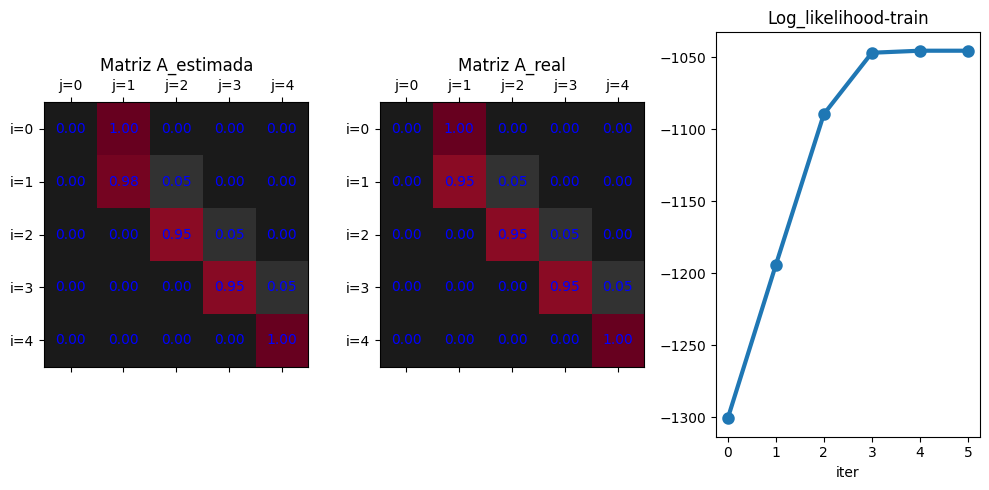

In [12]:
likelihood = bw_model.history_likehood()

A_trained = bw_model.hmm.trans

µy = bw_model.hmm.means
Σ = bw_model.hmm.vrs

A_real = HMM[4].trans

fig, axs = plt.subplots(1, 3, figsize=(10, 5))

# Primer gráfico: A_traines
axs[0].matshow(A_trained, cmap='RdGy_r')
axs[0].set_xticks(np.arange(A_trained.shape[1]))
axs[0].set_xticklabels([f"j={i}" for i in range(A_trained.shape[1])])
axs[0].set_yticks(np.arange(A_trained.shape[0]))
axs[0].set_yticklabels([f"i={j}" for j in range(A_trained.shape[0])])
axs[0].set_title("Matriz A_estimada")
for i, j in np.ndindex(A_trained.shape):
    axs[0].text(j, i, f"{A_trained[i, j]:.2f}", ha='center', va='center', color='blue')

# Segundo gráfico: A_real
axs[1].matshow(A_real, cmap='RdGy_r')
axs[1].set_xticks(np.arange(A_real.shape[1]))
axs[1].set_xticklabels([f"j={i}" for i in range(A_real.shape[1])])
axs[1].set_yticks(np.arange(A_real.shape[0]))
axs[1].set_yticklabels([f"i={j}" for j in range(A_real.shape[0])])
axs[1].set_title("Matriz A_real")
for i, j in np.ndindex(A_real.shape):
    axs[1].text(j, i, f"{A_real[i, j]:.2f}", ha='center', va='center', color='blue')


# Segundo gráfico: A_real
axis_ = range(len(likelihood))
axs[2].plot(axis_, likelihood, lw=3)
axs[2].scatter(axis_, likelihood, lw=3)
axs[2].set_title("Log_likelihood-train")
axs[2].set_xlabel("iter")

plt.tight_layout()
plt.show()

Vemos que la matriz de transición se parece bastante a la real, y como la likelihood convergio a un valor.

Esto quiere decir que el algoritmo encontro algun maximo local bastante decente.

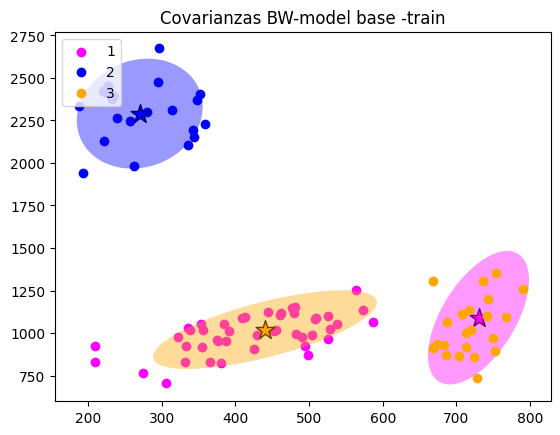

In [13]:
_, _ = plot_cov(X_train, Z_train[1:-1], HMM[3], 'Covarianzas BW-model base -train')

No se pide pero debido a que parece haber un problema en la clasificación se calcula la matriz de confusión siguiente para analizar los resultados.

Se concluye que hay un error en el orden de covarianzas del modelo, si no es que existe algun error en mi implementación.

Esto no afecta a las conlusiones obtenidas.

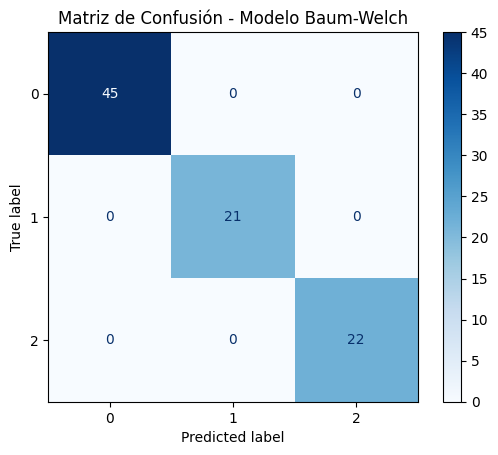

<Figure size 1000x800 with 0 Axes>

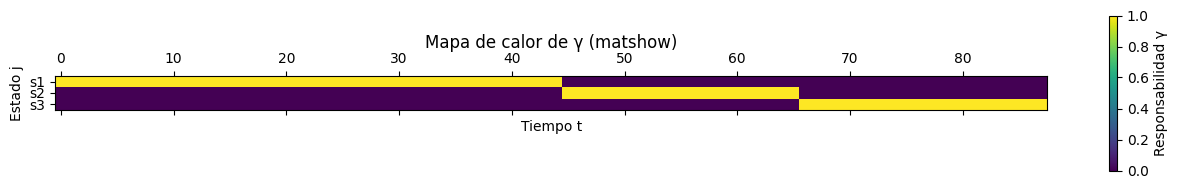

In [14]:

y_train = Z_train[1:-1]
y_pred = bw_model.predict(X_train) +1
cm = confusion_matrix(y_train, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Matriz de Confusión - Modelo Baum-Welch")
plt.show()

T = y_pred.shape[0]

one_hot = np.zeros((3, T))
one_hot[y_pred-1, np.arange(T)] = 1

plt.figure(figsize=(10, 8))
plt.matshow(one_hot, cmap='viridis')
plt.colorbar(label='Responsabilidad γ')
plt.title('Mapa de calor de γ (matshow)', pad=20)
plt.xlabel('Tiempo t')
plt.ylabel('Estado j')


plt.yticks(ticks=np.arange(one_hot.shape[0]), labels=[f"s{j+1}" for j in range(one_hot.shape[0])])

plt.show()

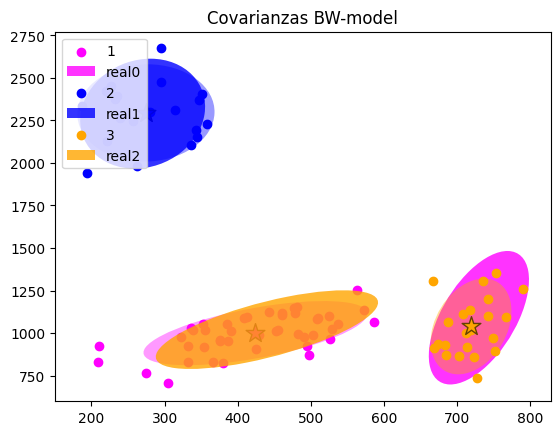

In [15]:
ellipse = []
#colours = ['magenta', 'blue', 'orange']
color = ['magenta', 'blue', 'orange']
for i in range(3):
    ellipse.append(get_cov_ellipse(HMM[3].vrs[i], HMM[3].means[i],1.7, fc=color[i], alpha=0.8))
    ellipse[i].set_label(f"real{i}")


fig, ax = plot_cov(X_train, bw_model.predict(X_train)+1, bw_model.hmm, 'Covarianzas BW-model', ellipse=ellipse)
# las elipses solidas son las originales.


Finalmente para esta primer parte se presentan la evolucion del algortimo

Ok, ahora veamos las muestras y sus covarianzas, vemos que dio muy parecido, se puede ver una diferencia en los colores de las clases y covarianzas pero esto es debido a un defecto en el set de muestras.

Además, se descarta el haberse equivocado con las clases debido a que la matris de transcición es la esperada y por las dudas se obtuvo la matriz de confusión la cual arroja todos los resultados exitosos!

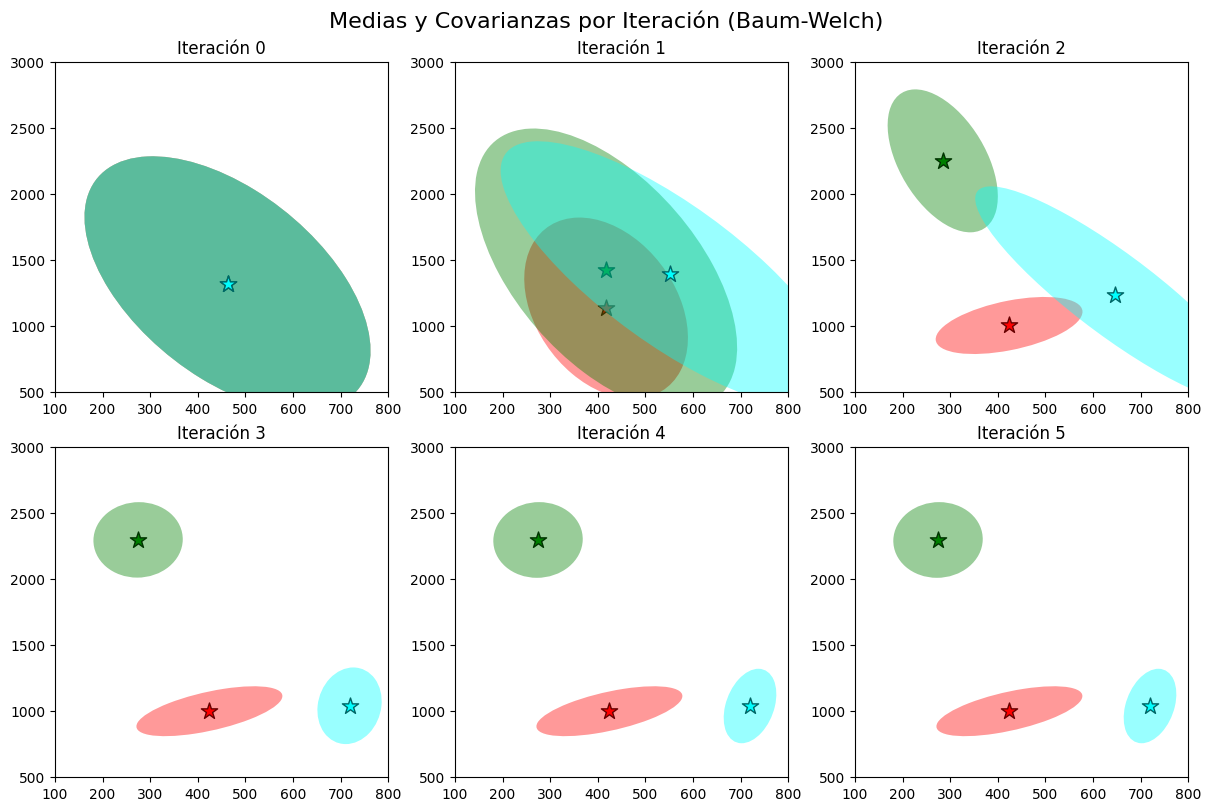

In [16]:
bw_model_mu = bw_model.mu
bw_model_var = bw_model.var


colors = ['red', 'green', 'cyan']

fig, axes = plt.subplots(2, 3, figsize=(4 * 3, 4*2), constrained_layout=True)

for idx in range(6):
    ax  = axes[idx//3, idx%3]
    mu  = bw_model_mu[idx]
    var = bw_model_var[idx]
    ax.set_title(f"Iteración {idx}")
    ax.set_xlim(100, 800)
    ax.set_ylim(500, 3000)
    for i in range(3):
        ax.scatter(mu[i][0], mu[i][1], color=colors[i], marker='*', s=150, edgecolors='black')
        ellipse = get_cov_ellipse(var[i], mu[i], 1.7, fc=colors[i], alpha=0.4)
        ax.add_patch(ellipse)

plt.suptitle("Medias y Covarianzas por Iteración (Baum-Welch)", fontsize=16)
plt.show()

El grafico anterior muestra la evolucion de las matrices de covarianza y sus meadias.
Partiendo de una covarianza inicial para las tres clases rapidamente evoluciona hacia un estado en donde las covarianzas no varian mucho mas, en la practica es cuando la likelihood converge.

Tenemos un modelo de evaluacion, usemoslo para ver que tan bien funciona.

Se nos proporciona solo 'X' por lo que podremos ver las covarianzas.

In [17]:
x_eval = loadmat('secuencia_evaluacion_BW_fuentes.mat')

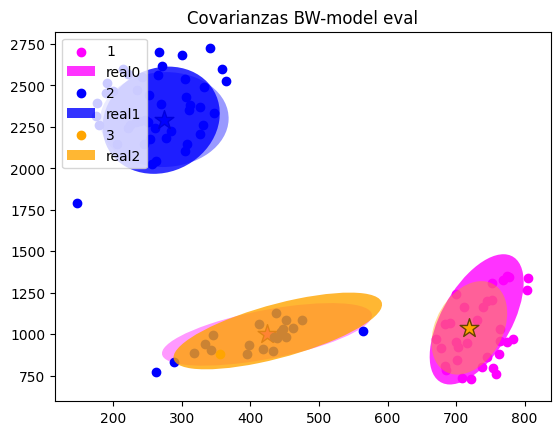

In [18]:
ellipse = []
for i in range(3):
    ellipse.append(get_cov_ellipse(HMM[3].vrs[i], HMM[3].means[i],1.7, fc=color[i], alpha=0.8))
    ellipse[i].set_label(f"real{i}")

fig, ax = plot_cov(x_eval['X'], bw_model.predict(x_eval['X'])+1, bw_model.hmm, 'Covarianzas BW-model eval', ellipse=ellipse)



Notar que con set de evaluación suministrado tambien se generan covarianzas consistentes.

El modelo de Baum-Wech funciona muy bien.

## 2

Se debe realizar una detección de modelos recorridos utilizando el algoritmo de Viterbi. Construya un modelo oculto de Markov que sea la composición de los modelos HMM[3] y HMM[5]. Este modelo compuesto tendrá entonces 6 estados emisores, cuyas probabilidades de emisión serán las de los modelos originales. La matriz de transición compuesta será tal que haya igual probabilidad de empezar en uno o en otro, de repetir un modelo u otro, y de terminar después de haber llegado a cualquiera de sus estados finales. Debe notarse que este modelo tendrá una matriz de transición de 8 por 8 estados, que utilizará las transiciones de los modelos originales dentro de los estados interiores, y se completará el resto de modo de obtener el comportamiento pedido.
   - Se suministra una secuencia $X_{46}$ que se sabe que fue generada con un modelo como el descripto. Se debe obtener la secuencia de estados recorridos más probable.

   - A partir de los estados recorridos, determine la secuencia de modelos ocurrida, suponiendo que los estados 1, 2 y 3 corresponden al modelo original HMM[3] mientras que el 4, 5 y 6 corresponden al modelo original HMM[5].


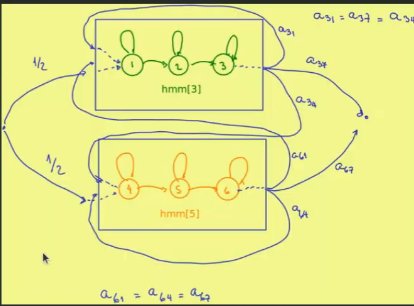

La matriz de transición que hay que armar es la siguiente:

$$
A_{Viterbi} =
\begin{bmatrix}
A^{(3)} & B \\
C & A^{(5)}
\end{bmatrix}
=
\begin{bmatrix}
A^{(3)} &
\begin{matrix}
a_{14} & a_{15} & a_{16} & 0 \\
a_{24} & a_{25} & a_{26} & 0 \\
a_{34} & a_{35} & a_{36} & 0
\end{matrix}
\\
\begin{matrix}
0 & a_{41} & a_{42} & a_{43} \\
0 & a_{51} & a_{52} & a_{53} \\
0 & a_{61} & a_{62} & a_{63} \\
0 & a_{71} & a_{72} & a_{73} \\
0 & 0 & 0 & 0
\end{matrix}
&
A^{(5)}
\end{bmatrix}
$$

en donde todas las $a_{ij}$ que no perteneces a las submatrices $A^{i}$ se inicializan con cero y como $a_{34}=a_{37}=a_{31}$ entonces se suma a lo largo de la fila 3 y se les asigna el valor resultate dividido 3.

de forma analoga para la fila 6 donde $a_{61}=a_{64}=a_{67}$.

Tambien $a_{01} = a_{04} =0.5$

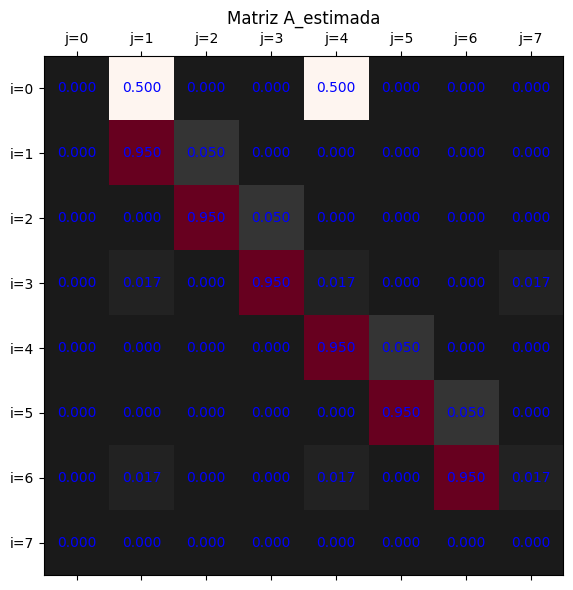

In [19]:
A11 = HMM[3].trans[1:-1,1:-1]
A22 = HMM[5].trans[1:-1,1:-1]

lenH = len(A11)
lenA = lenH*2 + 2

vitA = np.zeros((lenA, lenA))
vitA[1:lenH+1, 1:lenH+1]               = A11
vitA[lenH+1:2*lenH+1, lenH+1:2*lenH+1] = A22

vitA[0,1]=0.5; vitA[0,4]=0.5

#a34=a37=a31
vitA[3,[1,4,7]] = (1 - vitA[3,:].sum())/3
#a61=a64=a67
vitA[6,[1,4,7]] = (1 - vitA[6,:].sum())/3


fig, axs = plt.subplots(figsize=(6, 6))
cax = axs.matshow(vitA, cmap='RdGy_r')

axs.set_xticks(np.arange(lenA))
axs.set_xticklabels([f"j={i}" for i in range(lenA)])
axs.set_yticks(np.arange(lenA))
axs.set_yticklabels([f"i={j}" for j in range(lenA)])
axs.set_title("Matriz A_estimada")

for i in range(lenA):
    for j in range(lenA):
        axs.text(j, i, f"{vitA[i, j]:.3f}", ha='center', va='center', color='blue')

plt.tight_layout()
plt.show()


Con la matriz de transición y las medias y covarianzas ya se puede armar el modelo.

In [20]:
means = np.ones((6,2))
means[:3] = HMM[3].means; means[3:] = HMM[5].means

vrs   = np.ones((6, 2,2))
vrs[:3] = HMM[3].vrs; vrs[3:] = HMM[5].vrs

trans = vitA

HMM35 = hmm(means, vrs, trans)

genero datos con el modelo

Text(0.5, 1.0, 'HMM35, secuencia X35, Z35')

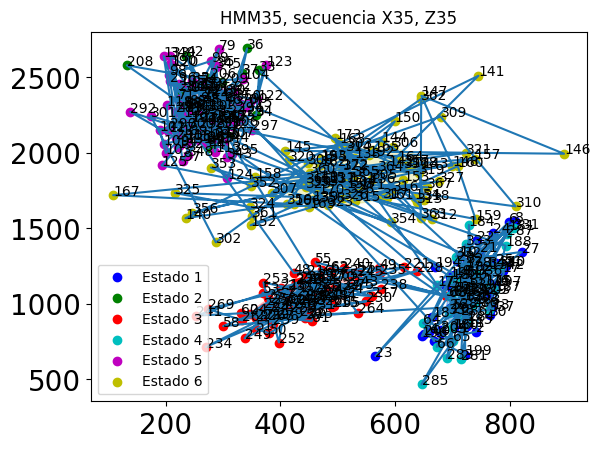

In [21]:
X35, Z35= genhmm(HMM35)
min_state = 20
while not (np.bincount(Z35)[1:-1] >= min_state).all():
 X35, Z35= genhmm(HMM35)
 #print(np.bincount(Z_train)[1:-1])


ax = plotseq2(HMM35, Z35, X35, gauss=True)
ax.set_title('HMM35, secuencia X35, Z35')


Cargamos la secuencia suministrada y lo visualizamos con plotSeq debido a que con plotSeq2 no se puede ver las secuencias de forma practica.

In [22]:
x = loadmat('secuencia_viterbi_fuentes.mat')

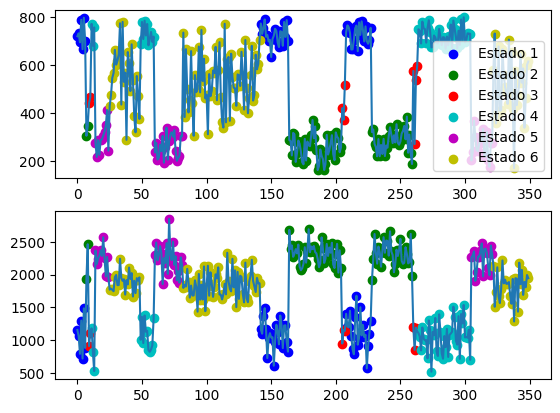

In [23]:
costOPt, log_pi, seq = logvit(x['X46'], HMM35)
ax = plotseq(HMM35, seq, x['X46'])


Bueno hasta acá la secuencia de estados para los datos $X46$ con el modelo HMM35.

Ahora habrá que detectar los estados **1,2,3** y **3,4,5** para asignarlos de $HMM[3]$ Y $HMM[5]$ respectivamente.

La estrategia será la siguiente:

se debe identificar los valores de inicio de secuencia, 1 y 3 dentro del loop, a medida que itera para toda la secuencia se agregara $hmm_i$ solo si se encuentra el valor de incio de secuencia y este es distinto al valor de secuencia anterior.


In [24]:

seq_ = seq[:-1]

#seq_init → etiqueta
patrones = {(1): "hmm3", (4): "hmm5"}
seq_hmm = []
for i, s in enumerate(seq_):
    if (s == 1) and (s!=seq_[i-1]): seq_hmm.append(patrones[(1)])
    if (s == 4) and (s!=seq_[i-1]): seq_hmm.append(patrones[(4)])

print(seq)
print(seq_hmm)


[0 1 1 1 1 1 1 1 2 2 3 3 4 4 4 5 5 5 5 5 5 5 5 5 5 5 6 6 6 6 6 6 6 6 6 6 6
 6 6 6 6 6 6 6 6 6 6 6 6 6 4 4 4 4 4 4 4 4 4 4 4 5 5 5 5 5 5 5 5 5 5 5 5 5
 5 5 5 5 5 5 5 5 5 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6
 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 3 3 3 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 3 3 3 3 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4
 4 4 4 4 4 4 4 4 4 4 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 6 6 6 6 6 6 6 6 6 6
 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 7]
['hmm3', 'hmm5', 'hmm5', 'hmm3', 'hmm3', 'hmm5']


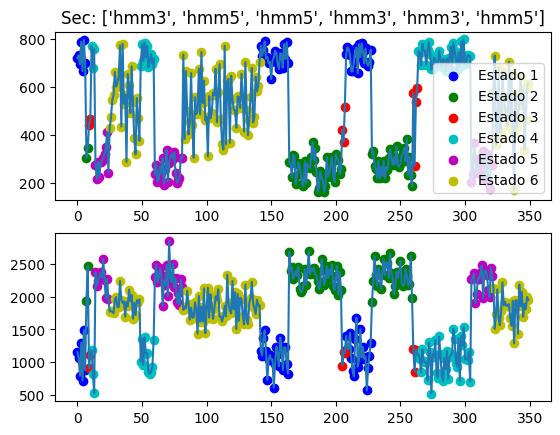

In [25]:
ax1, ax2 = plotseq(HMM35, seq, x['X46'])
#_ = ax2.set_xticks()
_= ax1.set_title(f"Sec: {seq_hmm}", wrap=True)


Notar  que en este grafico ya se pueden ver las secuencias de colores y distinguir entre modelos y con el algortimo que detecta modelo a partir de la secuencia optima esto puede ser confirmado, aunmque dependiendo el grafico la zona de deteccion se puede tornar dificil de ver igual funciona bien en el algortimo (tambien va a depender de la corrida)

> Nota: funciona bastante bien incluso con HMM34 que con modelo muy parecidos.